## IN_DATA
- `dat_traj`

## OUT_DATA
- `dat_map_{job}`

## VERSION

## PACKAGE

In [1]:
%load_ext autoreload
%autoreload 2

from src.utils import *
from src.metadata import *
from src.sparsemap import *

warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
# WALL-ONLY MAP BATCH: 6 traj x 2 mice + 5 random traj (17 jobs, 16K walltime)
seed_list = np.arange(5)
rotation_id_list = np.arange(6)

# get job lists
job_list_rand = [(0,seed,-1) for seed in seed_list]
job_list_mouse_3 = [(1,3,rot_id) for rot_id in rotation_id_list]
job_list_mouse_4 = [(1,4,rot_id) for rot_id in rotation_id_list]

# pack
job_batch_wallmap = {i+1: job for i, job in enumerate(job_list_rand + job_list_mouse_3 + job_list_mouse_4)}
len(job_batch_wallmap)

17

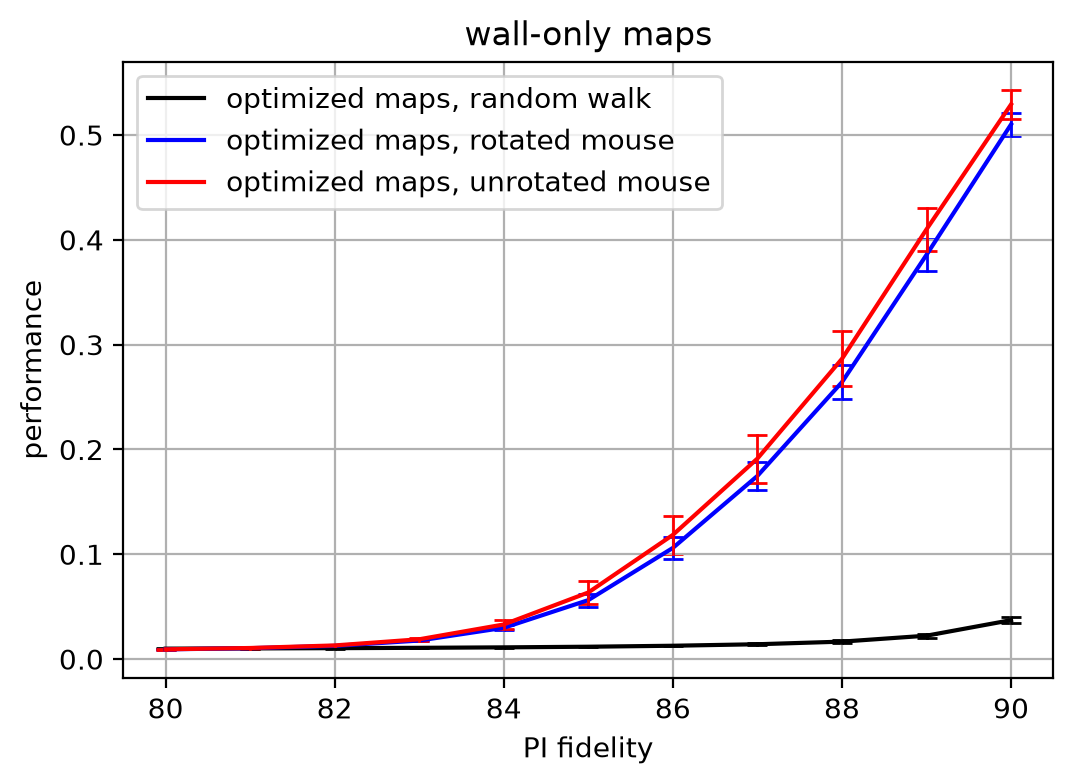

In [3]:
# load
pi_level_list = np.arange(80, 91, 1)
out_dir = project_dir / "results" / "data_wallmap"
score_tensor_rw = np.array([pickle.load(open(out_dir / f"dat_map_{x}", "rb"))[0] for x in [job_batch_wallmap[x] for x in [1,2,3,4,5]]])
score_tensor_rot = np.array([pickle.load(open(out_dir / f"dat_map_{x}", "rb"))[0] for x in [job_batch_wallmap[x] for x in [7,8,9,10,11,13,14,15,16,17]]])
score_tensor_unrot = np.array([pickle.load(open(out_dir / f"dat_map_{x}", "rb"))[0] for x in [job_batch_wallmap[x] for x in [6,12]]])

# prep
score_tensor_list = [score_tensor_rw, score_tensor_rot, score_tensor_unrot]
label_list = ['optimized maps, random walk', 'optimized maps, rotated mouse', 'optimized maps, unrotated mouse']
color_list = ['k', 'b', 'r']

# plot
plt.figure(figsize=(6, 4), dpi=200)
plt.title('wall-only maps')
for score_tensor, label, color in zip(score_tensor_list, label_list, color_list):
    # labels = [label] + ['']*(score_tensor.shape[0]-1)
    score_ci, score_mean, _ = get_confidence_interval(score_tensor, axis=0)
    plt.plot(pi_level_list, score_mean, label=label, color=color)
    for pi, ci0, ci1 in zip(pi_level_list, score_mean-score_ci, score_mean+score_ci):
        plt.plot([pi, pi], [ci0, ci1], color=color, lw=1)
    plt.scatter(pi_level_list, score_mean-score_ci, color=color, s=50, marker='_', lw=1)
    plt.scatter(pi_level_list, score_mean+score_ci, color=color, s=50, marker='_', lw=1)
plt.xlabel('PI fidelity')
plt.ylabel('performance')
plt.legend()
plt.grid()